# Lab 10: Gibbs Sampling

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import scipy

rng = np.random.default_rng(1337)

## Part 1: Gibbs Sampling with Binary Random Variables
Suppose we have two *Boolean* random variables $x$ and $y$, for which we would like to obtain the joint distribution $p(x,y)$.
If we know $p(x)$ and $p(y \mid x)$ (or $p(y)$ and $p(x \mid y)$), we can directly compute the joint distribution.

But now suppose that we only have access to the conditional probabilities $p(x \mid y = j)$ and $p(y \mid x = i)$. As we saw in the lecture, this is enough to approximate the joint distribution using *Gibbs sampling*. Recall from the lecture:
1. select a starting point $\mathbf z^{(0)}$
2. for $t = 1,2,\dots$:
   * for each $i = 1, \dots, K$, sample $z_i^{(t)} \sim p(z_i \mid z_1^{(t)},\dots,z_{i-1}^{(t)}, z_{i+1}^{(t-1)}, \dots, z_K^{(t-1)})$

#### Question 1
Implement Gibbs sampling for the above scenario. The conditional probabilities are provided as arrays `XgY` and `YgX`, respectively, so that, e.g., `XgY[i,j]` refers to $p(x = i \mid y = j)$.

In [ ]:
XgY = np.array([
    [0.8, 0.4],
    [0.2, 0.6]
])
YgX = np.array([
    [6/7, 0.5],
    [1/7, 0.5]
])

# TODO: Your code here...
def gibbs_sampling(x0: int, y0: int, n_samples: int = 1000):
    pass

The true joint distribution is given by:
||$y=0$|$y=1$|
|-|-|-|
|$x=0$|$0.6$|$0.1$|
|$x=1$|$0.15$|$0.15$|

Check whether your results are close.

## Part 2: Gaussian Mixture Models with pyMC and Gibbs Sampling

We consider a Gaussian Mixture Model (GMM) in one dimension. It consists of $K$ Gaussian distributions with different means and standard deviations, $\mathcal N(x \mid \mu_k, \sigma_k)$ for $k = 1,\dots,K$. The distributions are weighted according to $\boldsymbol\pi = (\pi_1,\dots,\pi_K)$ with $\pi_i > 0$ and $\sum \pi_i = 1$.
Setting $\boldsymbol\theta \coloneqq (\mu_1, \sigma_1,\dots,\mu_K,\sigma_K,\boldsymbol\pi)$, we can write the distribution of the GMM as
$$p(z = k, x \mid \boldsymbol\theta) = \pi_k \mathcal N(x \mid \mu_k, \sigma_k).$$
The prior over $\boldsymbol\theta$ is composed of a Dirichlet prior over $\boldsymbol\pi$, normal priors over the means and a half-normal distribution over the standard deviations:
$$p(\boldsymbol\theta) = \mathrm{Dir}(\boldsymbol\pi \mid \mathbf\alpha) \prod_{k=1}^K \mathcal N(\mu_k \mid m_0, s_0)\mathcal{HN}(\sigma_k \mid \nu).$$

For this task, we have $K = 3$ and the parameters $\boldsymbol\theta$ are unknown. 1000 data samples are contained in the file `data.txt`, the contents of which are plotted below.

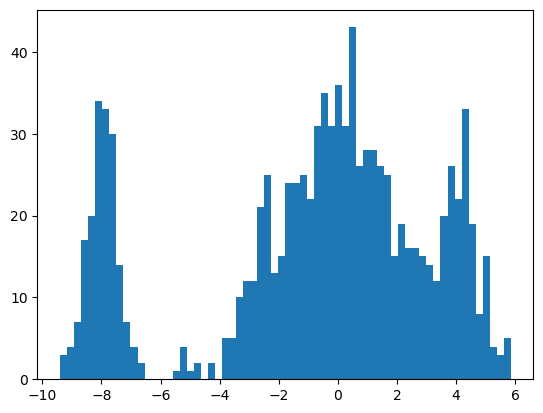

In [4]:
K = 3
x = np.loadtxt("data.txt")
plt.hist(x, 64);

#### Question 2
Implement the GMM using pyMC and sample using the NUTS sampler. The definition of `mu` is already provided to you. You can define a mixture model in pyMC using `pm.NormalMixture` (see docs: [pymc.NormalMixture](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.NormalMixture.html)). Make sure to include `dims="cluster"` as a keyword argument for every variable that should be indexed with $k$.

In [ ]:
with pm.Model(coords={"cluster": range(K)}) as model:
    mu = pm.Normal("mu", mu=0, sigma=5, transform=pm.distributions.transforms.ordered, initval=[-1,0,1], dims="cluster")
    sigma = ...
    pi = ...
    ...  # TODO: Define the GMM
    idata = pm.sample()

The code below plots the sampling result, along with grey lines at the true values:

In [ ]:
lines = [("mu", {}, [-8, 0, 4]), ("sigma", {}, [0.5, 2.0, 0.75])]
az.plot_trace(idata, var_names=["mu", "sigma", "pi"], lines=lines);

#### Question 3
The true parameters are $(\mu_1,\sigma_1) = (-8, 0.5)$, $(\mu_2,\sigma_2) = (0, 2.0)$, $(\mu_1,\sigma_1) = (4, 0.75)$ and $\boldsymbol\pi = (\frac{1}{6},\frac{2}{3},\frac{1}{6})$.
Use this information to generate from the joint distribution using Gibbs sampling with 2-dimensional state vectors of the form $(z,x)$. To this end, first write down expressions for the conditional distributions $p(z \mid x)$ and $p(x \mid z)$, then adapt your code from Question 1.

In [ ]:
mus = np.array([-8, 0, 4])
sigmas = np.array([0.5, 2.0, 0.75])
pi = np.array([1/6, 2/3, 1/6])

def gibbs_sampling_gmm(z0, x0, mus, sigmas, pi, n_iter=1000):
    pass

#### Question 4
Extend the histogram plot of the data above with your Gibbs samples.

In [ ]:
plt.figure()
plt.hist(x, 64)
...  # TODO: plot Gibbs samples